In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

activity = pd.read_csv("../data/processed/site_month_clean.csv")

print(activity.shape)
activity.head()

(28154, 65)


C:\Users\antwi\AppData\Local\Temp\ipykernel_32424\827670378.py:5: DtypeWarning: Columns (52) have mixed types. Specify dtype option on import or set low_memory=False.
  activity = pd.read_csv("../data/processed/site_month_clean.csv")


,__ID,_id_site,_Year,_Month,DateForSearch,zzCreationTS,zzModificationTS,AdultsReg,ChildrenReg,HouseholdsReg,...,IndividualsPerHH,id_agency,PoundsPerHH,stable_type,__ID_org,isDistributionSite,isAgency,isActive,block_geoid,location_resolved
0,2753,1254.0,2022,1,2022-01-01,2022-01-10T21:48:14Z,2025-12-30T13:50:18Z,1519.0,1048.0,1027.0,...,3.0,NaN,40.0,Food Shelf,1254.0,1.0,NaN,1.0,2.713701e+14,True
1,2762,14434.0,2022,1,2022-01-01,2022-01-10T15:01:29Z,2025-12-30T13:50:18Z,23.0,16.0,17.0,...,3.0,14434.0,53.0,Food Shelf,14434.0,1.0,NaN,1.0,2.710900e+14,True
2,12862,1069.0,2022,3,2022-03-01,2022-03-02T16:18:49Z,2026-09-02T20:20:24Z,281.0,27.0,220.0,...,2.0,16988.0,97.0,Food Shelf,1069.0,1.0,NaN,1.0,2.705311e+14,True
3,12863,1069.0,2022,1,2022-01-01,2022-03-08T09:50:31Z,2026-09-02T20:20:24Z,281.0,21.0,216.0,...,2.0,16988.0,73.0,Food Shelf,1069.0,1.0,NaN,1.0,2.705311e+14,True
4,12864,14680.1,2022,1,2022-01-01,2022-03-08T09:50:31Z,2025-12-30T13:50:24Z,142.0,93.0,91.0,...,3.0,NaN,63.0,Tribal Program,14680.1,1.0,NaN,1.0,2.713702e+14,True


In [2]:
activity_2024 = activity[
    (activity["_Year"] == 2024) &
    (activity["County"].notna()) &
    (activity["stable_type"] != "Meal Program")
].copy()

print("Rows:", len(activity_2024))
print("Counties:", activity_2024["County"].nunique())

Rows: 5619
Counties: 86


In [3]:
county_month = (
    activity_2024
    .groupby(
        ["County", "_Year", "_Month"],
        as_index=False
    )
    .agg(
        visits=("HouseholdsReg", "sum"),
        individuals=("IndividualsReg", "sum"),
        pounds=("PoundsReg", "sum")
    )
)

display(county_month.head())

print("Rows:", len(county_month))
print("Counties:", county_month["County"].nunique())

,County,_Year,_Month,visits,individuals,pounds
0,Aitkin,2024,1,256.0,605.0,14004.0
1,Aitkin,2024,2,260.0,573.0,13869.8
2,Aitkin,2024,3,261.0,593.0,13426.0
3,Aitkin,2024,4,382.0,803.0,18628.0
4,Aitkin,2024,5,350.0,689.0,24305.0


Rows: 1032
Counties: 86


In [4]:
month_counts = (
    county_month
    .groupby("County")["_Month"]
    .nunique()
    .reset_index(name="months_present")
)

print(month_counts["months_present"].value_counts())

display(
    month_counts[
        month_counts["months_present"] < 12
    ]
)

months_present
12    86
Name: count, dtype: int64


,County,months_present


In [5]:
county_2024 = (
    county_month
    .groupby("County", as_index=False)
    .agg(
        visits=("visits", "mean"),
        individuals=("individuals", "mean"),
        pounds=("pounds", "mean")
    )
)

print("Shape:", county_2024.shape)

display(county_2024.head())

Shape: (86, 4)


,County,visits,individuals,pounds
0,Aitkin,330.916667,719.416667,18017.975000
1,Anoka,19465.083333,72999.083333,774816.833333
2,Becker,543.750000,1736.750000,51284.916667
3,Beltrami,1250.333333,3717.333333,86149.179167
4,Benton,673.083333,1693.750000,36775.416667


In [6]:
acs = pd.read_csv(
    "../data/public/acs_county.csv",
    dtype={"fips": str}
)

acs_2024 = acs[
    acs["year"] == 2024
].copy()

print(acs_2024.shape)
display(acs_2024.head())

(87, 9)


,fips,year,county,population,poverty_rate,snap_hh_rate,poor_no_snap_rate,med_income,no_vehicle_rate
174,27001,2024,Aitkin,16056,0.131130,0.089449,0.095957,60833,0.049709
175,27003,2024,Anoka,370349,0.070194,0.071665,0.048773,101869,0.046459
176,27005,2024,Becker,35343,0.129006,0.115753,0.064608,71388,0.057807
177,27007,2024,Beltrami,46512,0.161380,0.134658,0.082269,68975,0.058882
178,27009,2024,Benton,41593,0.098657,0.085651,0.061367,74410,0.061248


In [7]:
county_table = county_2024.merge(
    acs_2024[
        [
            "fips",
            "county",
            "population",
            "poverty_rate",
            "snap_hh_rate",
            "poor_no_snap_rate",
            "med_income",
            "no_vehicle_rate"
        ]
    ],
    left_on="County",
    right_on="county",
    how="left"
)

print("Shape:", county_table.shape)

print("\nMissing values:")
print(county_table.isna().sum())

Shape: (86, 12)

Missing values:
County               0
visits               0
individuals          0
pounds               0
fips                 0
county               0
population           0
poverty_rate         0
snap_hh_rate         0
poor_no_snap_rate    0
med_income           0
no_vehicle_rate      0
dtype: int64


In [8]:
rural = pd.read_csv(
    "../data/public/rural_codes.csv",
    dtype={"fips": str}
)

county_table = county_table.merge(
    rural[
        ["fips", "rucc", "metro"]
    ],
    on="fips",
    how="left",
    validate="one_to_one"
)

print("Shape:", county_table.shape)

print("\nMissing values:")
print(county_table.isna().sum())

print("\nMetro counts:")
print(county_table["metro"].value_counts())

Shape: (86, 14)

Missing values:
County               0
visits               0
individuals          0
pounds               0
fips                 0
county               0
population           0
poverty_rate         0
snap_hh_rate         0
poor_no_snap_rate    0
med_income           0
no_vehicle_rate      0
rucc                 0
metro                0
dtype: int64

Metro counts:
metro
False    59
True     27
Name: count, dtype: int64


In [9]:
county_table.describe()

,visits,individuals,pounds,population,poverty_rate,snap_hh_rate,poor_no_snap_rate,med_income,no_vehicle_rate,rucc
count,86.000000,86.000000,8.600000e+01,8.600000e+01,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,2754.510659,8625.562016,1.494442e+05,6.666365e+04,0.102010,0.084848,0.069689,77571.465116,0.054265,5.662791
std,9496.770227,29952.477415,4.892256e+05,1.595378e+05,0.027995,0.030162,0.016367,13036.370587,0.017320,2.920961
min,45.500000,100.333333,2.821400e+03,3.243000e+03,0.044217,0.029719,0.037523,59441.000000,0.023665,1.000000
25%,246.541667,695.604167,1.556892e+04,1.125825e+04,0.084064,0.065477,0.060577,70654.750000,0.041642,3.000000
50%,551.083333,1434.916667,3.566592e+04,2.275450e+04,0.102863,0.083719,0.068387,74221.500000,0.051913,6.000000
75%,1212.562500,3113.020833,6.465491e+04,4.497600e+04,0.121711,0.099454,0.081109,79807.750000,0.060433,8.000000
max,80605.750000,246237.416667,4.228622e+06,1.269496e+06,0.183397,0.213793,0.113490,125946.000000,0.102378,9.000000


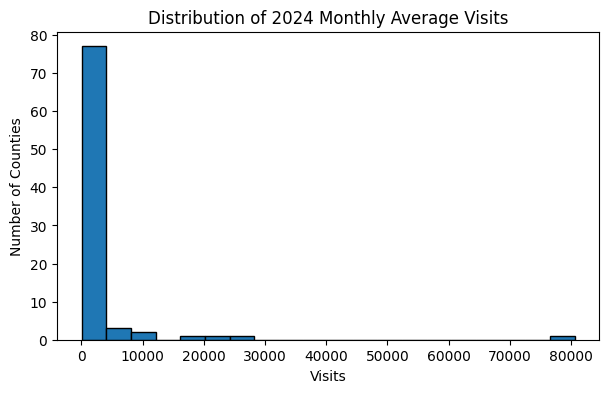

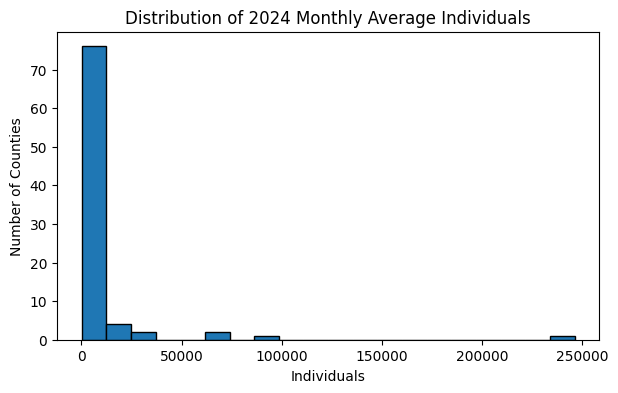

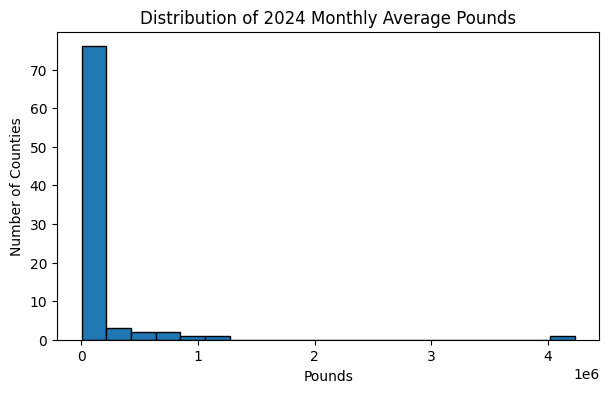

In [10]:
activity_vars = ["visits", "individuals", "pounds"]

for variable in activity_vars:
    plt.figure(figsize=(7, 4))
    
    plt.hist(
        county_table[variable],
        bins=20,
        edgecolor="black"
    )
    
    plt.title(f"Distribution of 2024 Monthly Average {variable.title()}")
    plt.xlabel(variable.title())
    plt.ylabel("Number of Counties")
    
    plt.show()

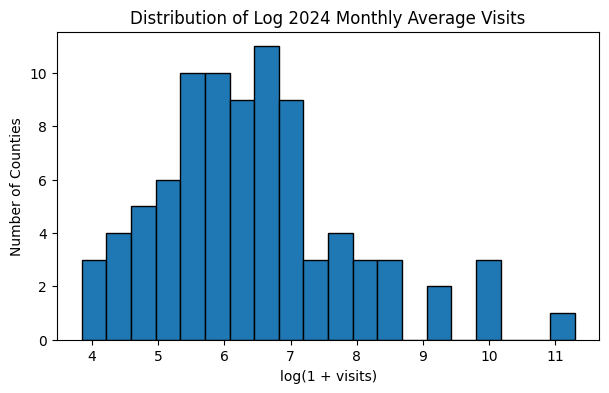

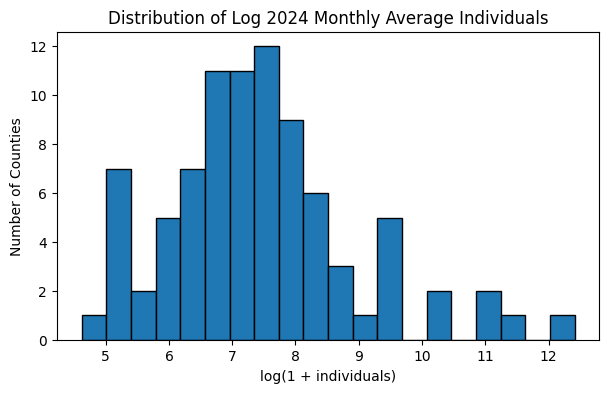

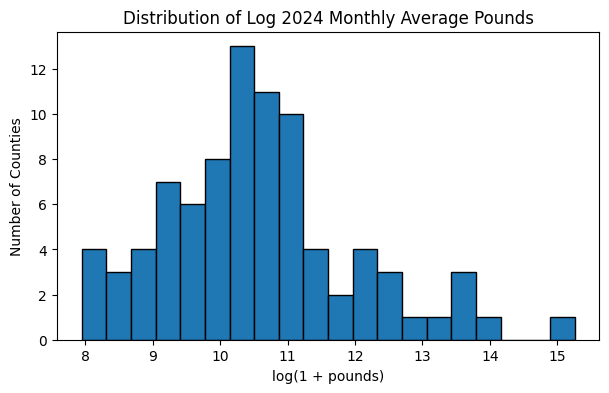

In [11]:
for variable in activity_vars:
    plt.figure(figsize=(7, 4))
    
    plt.hist(
        np.log1p(county_table[variable]),
        bins=20,
        edgecolor="black"
    )
    
    plt.title(f"Distribution of Log 2024 Monthly Average {variable.title()}")
    plt.xlabel(f"log(1 + {variable})")
    plt.ylabel("Number of Counties")
    
    plt.show()

In [12]:
county_table[
    ["visits", "individuals", "pounds"]
].skew()

visits         6.941334
individuals    6.500208
pounds         7.179928
dtype: float64

All three food-shelf activity measures are strongly right-skewed across counties. After the mirror-feed correction, the skewness values are approximately 6.94 for visits, 6.50 for individuals served, and 7.18 for pounds distributed. Much of this raw skew reflects large differences in county population.

Basically  the county-level activity distributions are extremely right-skewed.

In [13]:
# Keeping only one county-name column
if "county" in county_table.columns:
    county_table = county_table.drop(columns=["county"])

print(county_table.shape)
print(county_table.columns.tolist())

(86, 13)
['County', 'visits', 'individuals', 'pounds', 'fips', 'population', 'poverty_rate', 'snap_hh_rate', 'poor_no_snap_rate', 'med_income', 'no_vehicle_rate', 'rucc', 'metro']


In [14]:
mmg = pd.read_excel(
    "../data/FeedingAmericaData/MMG2026_2024_Data_To_Share.xlsx",
    sheet_name="County"
)

print(mmg.shape)
print(mmg.columns.tolist())

mmg_2024 = mmg[
    (mmg["State"] == "MN") &
    (mmg["Year"] == 2024)
].copy()

print(mmg_2024.shape)

mmg_2024["fips"] = (
    pd.to_numeric(mmg_2024["FIPS"], errors="coerce")
    .astype("Int64")
    .astype(str)
    .str.zfill(5)
)
mmg_2024["need_people_month"] = (
    mmg_2024["# of Food Insecure Persons Overall"] * 7 / 12
)

(3144, 25)
['FIPS', 'State', 'County, State', 'Year', 'Overall Food Insecurity Rate', '# of Food Insecure Persons Overall', 'Food Insecurity Rate among Black Persons (all ethnicities)', 'Food Insecurity Rate among Hispanic Persons (any race)', 'Food Insecurity Rate among White, non-Hispanic Persons', 'SNAP Threshold', '% FI ≤ SNAP Threshold', '% FI > SNAP Threshold', 'Child Food Insecurity Rate', '# of Food Insecure Children', '% food insecure children in HH w/ HH incomes below 185 FPL', '% food insecure children in HH w/ HH incomes above 185 FPL', 'Imputed Market Basket Data', 'Cost Per Meal', 'Weighted weekly $ needed by FI', 'Weighted Annual Food Budget Shortfall', 'Rural-Urban Continuum Code (2013)', 'Rural-Urban Continuum Code (2023)', 'Census Region', 'Census Division', 'FNS Region']
(87, 25)


In [15]:
need_2024 = mmg_2024[
    ["fips", "need_people_month"]
].copy()

county_table = county_table.merge(
    need_2024,
    on="fips",
    how="left",
    validate="one_to_one"
)

print("Shape:", county_table.shape)

print("\nMissing need:")
print(county_table["need_people_month"].isna().sum())

Shape: (86, 14)

Missing need:
0


In [16]:
county_table["visits_per_1000"] = (
    county_table["visits"]
    / county_table["population"]
    * 1000
)

print("Population skew:",
      county_table["population"].skew())

print("Visits skew:",
      county_table["visits"].skew())

print("Visits per 1,000 skew:",
      county_table["visits_per_1000"].skew())

Population skew: 5.746576706373994
Visits skew: 6.941334220278782
Visits per 1,000 skew: 2.5983186878436286


In [17]:
bank_counts = (
    activity_2024
    .dropna(subset=["FoodBank"])
    .groupby(
        ["County", "FoodBank"]
    )
    .size()
    .reset_index(name="report_rows")
)

main_bank = (
    bank_counts
    .sort_values(
        ["County", "report_rows"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset="County"
    )
    [["County", "FoodBank"]]
    .rename(
        columns={"FoodBank": "main_food_bank"}
    )
)

county_table = county_table.merge(
    main_bank,
    on="County",
    how="left",
    validate="one_to_one"
)

display(main_bank.head())

,County,main_food_bank
0,Aitkin,Second Harvest Northland
1,Anoka,Second Harvest Heartland
2,Becker,North Country Food Bank
3,Beltrami,North Country Food Bank
5,Benton,Second Harvest Heartland


In [ ]:
activity_2024["reported"] = (
    activity_2024["HouseholdsReg"] > 0
)

county_month_reporting = (
    activity_2024
    .groupby(
        ["County", "_Month"],
        as_index=False
    )
    .agg(
        report_share=("reported", "mean")
    )
)

county_reporting = (
    county_month_reporting
    .groupby(
        "County",
        as_index=False
    )
    .agg(
        report_share=("report_share", "mean")
    )
)

county_table = county_table.merge(
    county_reporting,
    on="County",
    how="left",
    validate="one_to_one"
)

display(
    county_table[
        ["County", "report_share"]
    ]
    .sort_values("report_share")
    .head(10)
)

,County,report_share
3,Beltrami,0.591667
74,Stevens,0.750000
71,St. Louis,0.906556
54,Olmsted,0.921970
13,Clay,0.942766
21,Faribault,0.944444
42,Mahnomen,0.958333
53,Norman,0.958333
24,Goodhue,0.983333
59,Polk,0.986111


Raw visits are extremely skewed likely because Minnesota counties have radically different population sizes.

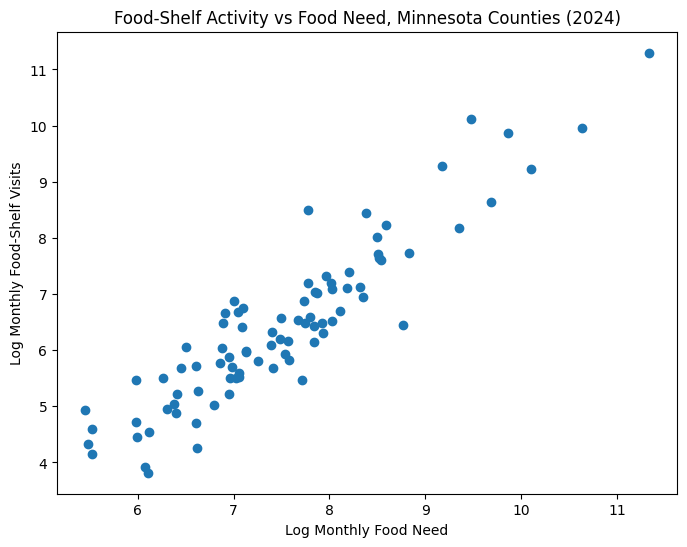

In [19]:
county_table["log_visits"] = np.log(
    county_table["visits"]
)

county_table["log_need"] = np.log(
    county_table["need_people_month"]
)

plt.figure(figsize=(8, 6))

plt.scatter(
    county_table["log_need"],
    county_table["log_visits"]
)

plt.xlabel("Log Monthly Food Need")
plt.ylabel("Log Monthly Food-Shelf Visits")
plt.title("Food-Shelf Activity vs Food Need, Minnesota Counties (2024)")

plt.show()

In [20]:
slope, intercept = np.polyfit(
    county_table["log_need"],
    county_table["log_visits"],
    1
)

correlation = county_table[
    ["log_need", "log_visits"]
].corr().iloc[0, 1]

print("Slope:", slope)
print("Correlation:", correlation)

Slope: 1.173229299207883
Correlation: 0.9202724315316402


log(visits)=a+1.176log(need)

In [21]:
county_table["predicted_log_visits"] = (
    intercept +
    slope * county_table["log_need"]
)

county_table["scatter_residual"] = (
    county_table["log_visits"] -
    county_table["predicted_log_visits"]
)

print("Highest above the relationship:")
display(
    county_table[
        ["County", "visits", "need_people_month",
         "scatter_residual"]
    ]
    .sort_values(
        "scatter_residual",
        ascending=False
    )
    .head(4)
)

print("Lowest below the relationship:")
display(
    county_table[
        ["County", "visits", "need_people_month",
         "scatter_residual"]
    ]
    .sort_values(
        "scatter_residual"
    )
    .head(4)
)

Highest above the relationship:


,County,visits,need_people_month,scatter_residual
73,Steele,4932.666667,2391.666667,1.746906
81,Washington,24896.000000,13113.333333,1.369321
64,Renville,966.583333,1102.500000,1.025599
65,Rice,4656.166667,4369.166667,0.982252


Lowest below the relationship:


,County,visits,need_people_month,scatter_residual
68,Scott,630.416667,6440.000000,-1.472476
51,Nicollet,236.083333,2240.000000,-1.215681
60,Pope,71.250000,746.666667,-1.124747
53,Norman,45.500000,449.166667,-0.976965


In [22]:
# Remove duplicate lowercase county column
if "county" in county_table.columns:
    county_table = county_table.drop(
        columns=["county"]
    )

final_columns = [
    "County",
    "fips",
    "visits",
    "individuals",
    "pounds",
    "need_people_month",
    "population",
    "visits_per_1000",
    "poverty_rate",
    "snap_hh_rate",
    "poor_no_snap_rate",
    "med_income",
    "no_vehicle_rate",
    "rucc",
    "metro",
    "main_food_bank",
    "report_share"
]

county_table_final = county_table[
    final_columns
].copy()

print("Shape:", county_table_final.shape)

print("\nMissing values:")
print(county_table_final.isna().sum())

county_table_final.to_csv(
    "../data/processed/county_table_2024.csv",
    index=False
)

Shape: (86, 17)

Missing values:
County               0
fips                 0
visits               0
individuals          0
pounds               0
need_people_month    0
population           0
visits_per_1000      0
poverty_rate         0
snap_hh_rate         0
poor_no_snap_rate    0
med_income           0
no_vehicle_rate      0
rucc                 0
metro                0
main_food_bank       0
report_share         0
dtype: int64


Need versus activity. Estimated monthly food need is strongly associated with food-shelf visits across Minnesota counties in 2024 (\(r=0.918\)). The log-log slope is 1.176, indicating that recorded visits increase slightly more than proportionally with estimated need. Raw visits are also strongly affected by county size: visit skewness falls from 6.91 to 2.61 after expressing visits per 1,000 residents. Several counties depart substantially from the overall need-activity relationship. Steele, Rice, Washington, and Renville lie furthest above the fitted relationship, while Scott, Nicollet, Pope, and Norman lie furthest below. These deviations are only descriptive